In [2]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
sys.path.append('../../') 
from consensus_variables import *

In [4]:
def plotMutationsPerCycle(df, sample_name):
    fig, ax = plt.subplots(figsize=(2.3, 1.7))
    
    # 1. Stacked Bar Plot
    margin_bottom = np.zeros(len(df))
    colors = {
        "C>A": '#5abdeb', "C>G": '#050708', "C>T": '#d43c32',
        "T>A": '#cbcacb', "T>C": '#aacb72', "T>G": '#e7c9c6'
    }

    for xIter in ["C>T", "C>A", "C>G", "T>A", "T>C", "T>G"]:
        df.plot.bar(x="Base", y=xIter, ax=ax, bottom=margin_bottom, color=colors[xIter])
        margin_bottom += df[xIter]

    # 2. X-Tick Filtering (Aligning index position with label)
    remaining_ticks = []
    remaining_labels = []

    for i, label in enumerate(ax.get_xticklabels()):
        try:
            val = int(label.get_text())
            if val % 25 == 0 or val in (0, 10):
                remaining_ticks.append(i)          # Use tick index i for placement
                remaining_labels.append(str(val))  # Use matching text value
        except ValueError:
            continue

    ax.set_xticks(remaining_ticks)
    ax.set_xticklabels(remaining_labels, rotation=0)

    # 3. Primary Axis Formatting
    ax.legend(frameon=False)
    ax.set_ylabel("Number of mutations")
    ax.set_xlabel("Position in read")
    ax.spines["right"].set_visible(False)
    ax.spines[:].set_linewidth(0.5)
    ax.tick_params(which='both', width=0.5)

    # 4. Secondary Line Plot (Plotted against positional index range)
    ax2 = ax.twinx()
    ax2.plot(
        range(len(df)), df['Count_percent'], 
        color="black", linewidth=0.5, linestyle=(0, (2, 2))
    )
    ax2.set_ylabel("Fraction of Total Reads")
    ax2.set_ylim(0, 1.02)
    ax2.spines["right"].set_linestyle((0, (2, 2)))
    ax2.spines[:].set_linewidth(0.5)
    ax2.tick_params(which='both', width=0.5)

    fig.savefig(f"plots/{sample_name}_BasePerPosWithoutNs.pdf", bbox_inches='tight', dpi=300)

In [5]:
sample_name = "152"
counts_data = pd.read_table(f"data/{sample_name}.duplex_MutsPerCycle.dat.csv", sep=",", index_col=0)
counts_data.head()

,C>T,C>A,C>G,T>A,T>C,T>G,C>N,T>N,Count,Base,Count_percent
0,0,0,0,0,0,0,0,0,0,1,0.0
1,0,0,0,0,0,0,0,0,0,2,0.0
2,0,0,0,0,0,0,0,0,0,3,0.0
3,0,0,0,0,0,0,0,0,0,4,0.0
4,0,0,0,0,0,0,0,0,0,5,0.0


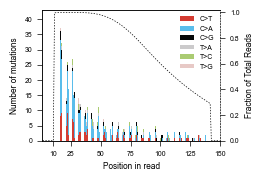

In [6]:
sample_name = "152"
counts_data = pd.read_table(f"data/{sample_name}.duplex_MutsPerCycle.dat.csv", sep=",", index_col=0)
plotMutationsPerCycle(counts_data, sample_name)

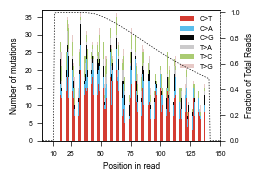

In [7]:
sample_name = "K_78_1_H_1"
counts_data = pd.read_table(f"data/{sample_name}.duplex_MutsPerCycle.dat.csv", sep=",", index_col=0)
plotMutationsPerCycle(counts_data, sample_name)